#Importing the Data

In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')


In [ ]:
import kagglehub

path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
data_dir = '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled'

def get_data_map(base_dir):
    data_map = {}
    for person_name in os.listdir(base_dir):
        person_path = os.path.join(base_dir, person_name)

        if os.path.isdir(person_path):
            images = [os.path.join(person_path, img) for img in os.listdir(person_path)]
            data_map[person_name] = images
    return data_map

all_data = get_data_map(data_dir)
print(f"Total individuals found: {len(all_data)}")


Total individuals found: 5749


Total Images in Dataset: 13233
Total Unique Individuals: 5749


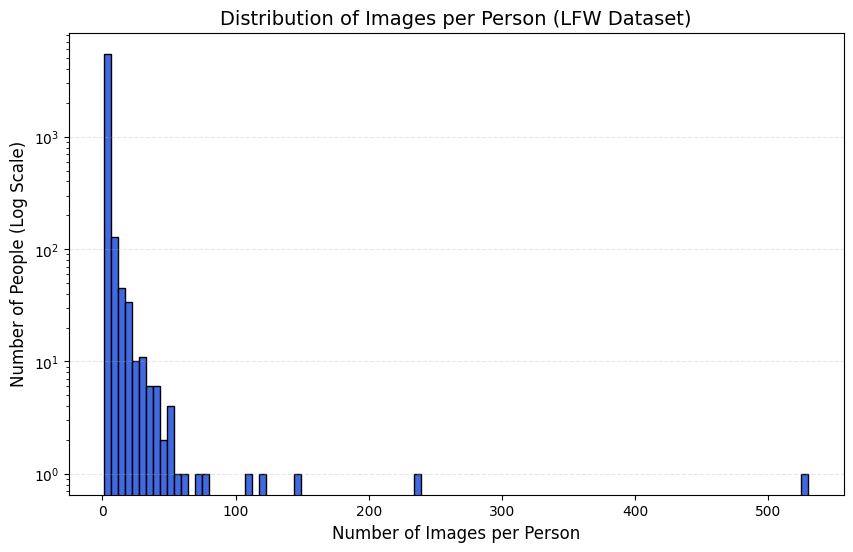

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate counts from your previously created 'all_data' dictionary
counts = [len(images) for images in all_data.values()]
total_images = sum(counts)
total_people = len(counts)

print(f"Total Images in Dataset: {total_images}")
print(f"Total Unique Individuals: {total_people}")

# 2. Generate Histogram
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=100, color='royalblue', edgecolor='black', log=True)

# Add Labels for Assignment Documentation
plt.title('Distribution of Images per Person (LFW Dataset)', fontsize=14)
plt.xlabel('Number of Images per Person', fontsize=12)
plt.ylabel('Number of People (Log Scale)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.show()


In [ ]:
import pandas as pd

counts = [len(imgs) for imgs in all_data.values()]

table_data = []
for i in range(1, 11):
    num_people = sum(1 for c in counts if c >= i)
    table_data.append({"Min Images": f"{i}+ Photos", "Number of Individuals": num_people})

df_stats = pd.DataFrame(table_data)
print(df_stats.to_string(index=False))


Min Images  Number of Individuals
 1+ Photos                   5749
 2+ Photos                   1680
 3+ Photos                    901
 4+ Photos                    610
 5+ Photos                    423
 6+ Photos                    311
 7+ Photos                    256
 8+ Photos                    217
 9+ Photos                    184
10+ Photos                    158


In [ ]:
# Apply the recommended threshold
THRESHOLD = 5

filtered_data = {name: imgs for name, imgs in all_data.items() if len(imgs) >= THRESHOLD}

print(f"Selected {len(filtered_data)} individuals for training/testing.")


Selected 423 individuals for training/testing.


In [ ]:
# Assuming you've already created filtered_data with the threshold of 5
total_filtered_photos = sum(len(images) for images in filtered_data.values())

print(f"Total photos of individuals with 5+ images: {total_filtered_photos}")


Total photos of individuals with 5+ images: 5985


In [ ]:
testing_data = {name: imgs for name, imgs in all_data.items() if len(imgs) < THRESHOLD}

print(f"Selected {len(testing_data)} individuals for training/testing.")

Selected 5326 individuals for training/testing.


In [ ]:
import random

# 1. Find a Similar Pair (Same Person)
# We need someone in testing_data who has at least 2 images
similar_candidates = [name for name, imgs in testing_data.items() if len(imgs) >= 2]

if similar_candidates:
    target_name = random.choice(similar_candidates)
    img_list = testing_data[target_name]
    # Pick two different photos of this same person
    sim_path1, sim_path2 = random.sample(img_list, 2)
    print(f"Similar Pair found for: {target_name}")
else:
    print("No one in testing_data has 2+ images to create a similar pair!")

# 2. Find a Dissimilar Pair (Different People)
# Pick two random different names from testing_data
diff_names = random.sample(list(testing_data.keys()), 2)
diff_path1 = random.choice(testing_data[diff_names[0]])
diff_path2 = random.choice(testing_data[diff_names[1]])
print(f"Dissimilar Pair found: {diff_names[0]} vs {diff_names[1]}")

Similar Pair found for: Marat_Safin
Dissimilar Pair found: T_Boone_Pickens vs George_Blaney


# Pre-Processing

In [ ]:
# 1. Split identities (80% for training, 20% for testing)
# This ensures a person in 'Train' is never seen in 'Val'
from sklearn.model_selection import train_test_split
train_names, val_names = train_test_split(list(filtered_data.keys()), test_size=0.2, random_state=42)

print(f"Training on {len(train_names)} people.")
print(f"Validating on {len(val_names)} people.")

Training on 338 people.
Validating on 85 people.


In [ ]:
# Calculate photo counts for training
train_photo_count = sum(len(filtered_data[name]) for name in train_names)

# Calculate photo counts for validation
val_photo_count = sum(len(filtered_data[name]) for name in val_names)

# Calculate photo counts for the "Zero-Shot" testing set
# This uses the testing_data dictionary we created earlier
test_names = list(testing_data.keys())
test_photo_count = sum(len(testing_data[name]) for name in test_names)

print(f"--- Dataset Statistics ---")
print(f"Training:   {len(train_names)} people, {train_photo_count} photos")
print(f"Validation: {len(val_names)} people, {val_photo_count} photos")
print(f"Testing:    {len(test_names)} people, {test_photo_count} photos")

--- Dataset Statistics ---
Training:   338 people, 4835 photos
Validation: 85 people, 1150 photos
Testing:    5326 people, 7248 photos


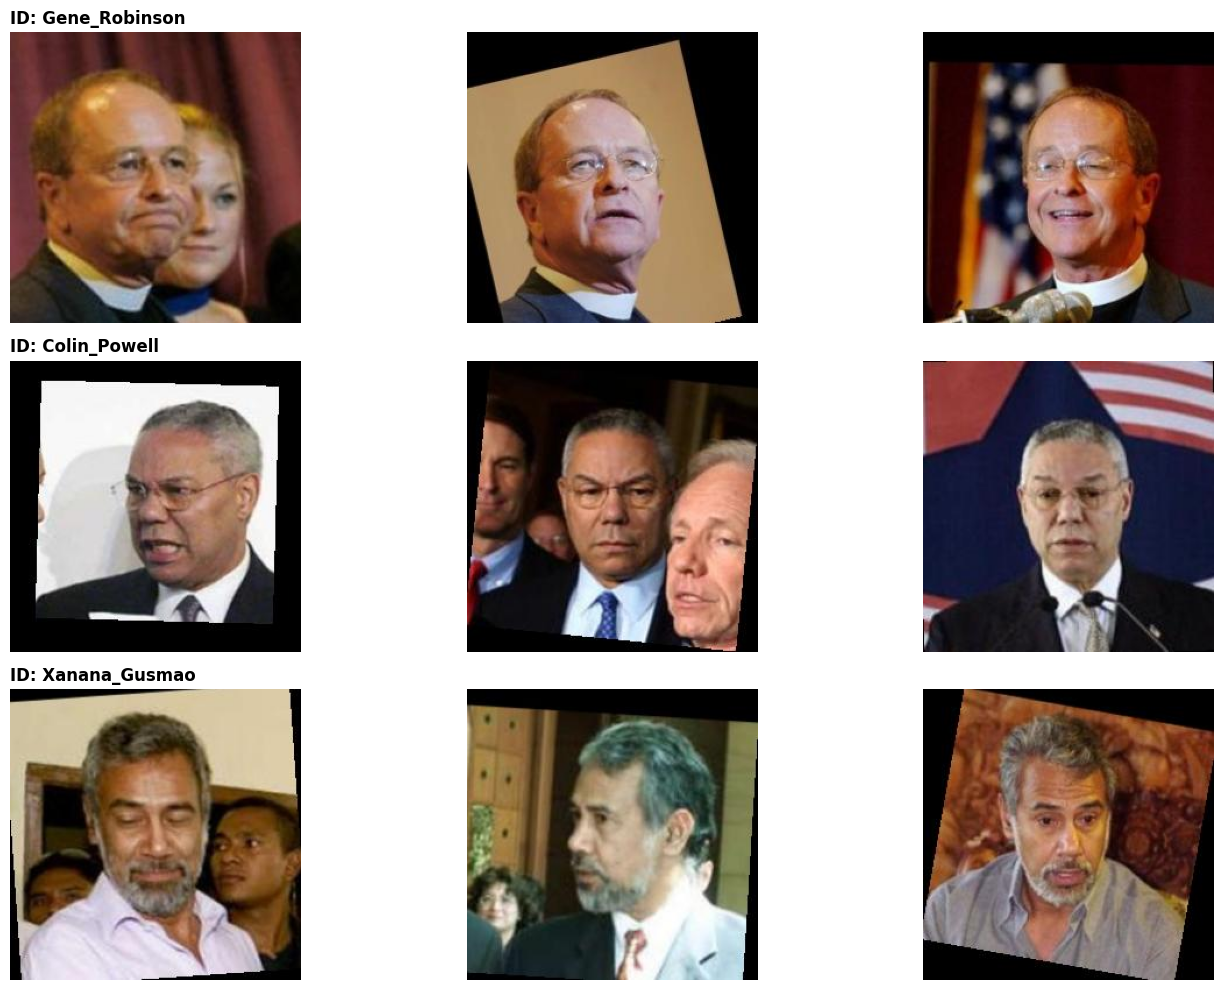

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_samples(data_dict, num_people=3, imgs_per_person=3):
    # Get the names of the first few people
    people = list(data_dict.keys())[:num_people]

    fig, axes = plt.subplots(num_people, imgs_per_person, figsize=(15, 10))

    for i, person in enumerate(people):
        img_paths = data_dict[person][:imgs_per_person]

        for j, path in enumerate(img_paths):
            img = Image.open(path)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f"ID: {person}", loc='left', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the function on your filtered data
plot_samples(filtered_data)


In [ ]:
import torchvision.transforms as transforms
from PIL import Image
# Apply this to EVERY image during training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),      # Randomly flips 50% of ALL images
    transforms.RandomRotation(10),          # Randomly rotates ALL images
    transforms.ColorJitter(brightness=0.1), # Randomly shifts lighting
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# For Validation/Testing: Only Resize and Normalize (NO random flips)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

class LFWDataset(Dataset):
    def __init__(self, names, data_dict, transform=None, target_count=None):
        self.names = names
        self.data_dict = data_dict
        self.transform = transform
        self.target_count = target_count # If set, we balance to this number

    def __len__(self):
        if self.target_count:
            return len(self.names) * self.target_count
        return sum(len(self.data_dict[name]) for name in self.names)

    def __getitem__(self, idx):
        if self.target_count:
            # Balancing Logic
            person_idx = idx // self.target_count
            name = self.names[person_idx]
            img_list = self.data_dict[name]
            img_path = img_list[idx % len(img_list)]
        else:
            # Standard Loading Logic (for Validation)
            name = self.names[idx % len(self.names)]
            img_path = self.data_dict[name][0]

        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, name

In [ ]:
import random
def transform_to_siamese(dataset):
    names = dataset.names
    data_dict = dataset.data_dict
    target_count = dataset.target_count if dataset.target_count else 5

    pairs = []
    labels = []

    for name in names:
        # Get the balanced list for this person
        img_list = data_dict[name][:target_count]

        # Ensure person has at least 2 images for a positive pair
        if len(img_list) < 2: continue

        for img1 in img_list:
            # 1. Positive Pair
            img2_pos = random.choice([img for img in img_list if img != img1])
            pairs.append((img1, img2_pos))
            labels.append(1.0)

            # 2. Negative Pair
            other_name = random.choice([n for n in names if n != name])
            img2_neg = random.choice(data_dict[other_name][:target_count])
            pairs.append((img1, img2_neg))
            labels.append(0.0)

    return pairs, labels

In [ ]:
import random

def transform_to_triplet(dataset):
    names = dataset.names
    data_dict = dataset.data_dict
    # Use the same balancing logic you had for pairs
    target_count = dataset.target_count if dataset.target_count else 5

    triplets = []

    for name in names:
        # Get the balanced list for this person (Anchor/Positive source)
        img_list = data_dict[name][:target_count]

        # We need at least 2 images of a person to create an Anchor-Positive pair
        if len(img_list) < 2:
            continue

        for anchor_img in img_list:
            # 1. Select Positive: A different image of the same person
            # We filter out the anchor so the model doesn't just learn to match identical files
            pos_img = random.choice([img for img in img_list if img != anchor_img])

            # 2. Select Negative: An image of a completely different person
            # To make it robust, we pick a random person from the other names
            other_name = random.choice([n for n in names if n != name])
            neg_img = random.choice(data_dict[other_name][:target_count])

            # Store as a triplet tuple
            triplets.append((anchor_img, pos_img, neg_img))

    return triplets

In [ ]:
import torch
class SiamesePairDataset(torch.utils.data.Dataset):
    def __init__(self, pairs, labels, transform=None):
        self.pairs = pairs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path = self.pairs[idx]
        label = self.labels[idx]

        img1 = Image.open(img1_path).convert('RGB')
        img2 = Image.open(img2_path).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [ ]:
import torch
from PIL import Image

class SiameseTripletDataset(torch.utils.data.Dataset):
    def __init__(self, triplets, transform=None):
        self.triplets = triplets
        self.transform = transform

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_path, pos_path, neg_path = self.triplets[idx]

        # Open images
        anchor = Image.open(anchor_path).convert('RGB')
        pos = Image.open(pos_path).convert('RGB')
        neg = Image.open(neg_path).convert('RGB')

        # Apply transforms
        if self.transform:
            anchor = self.transform(anchor)
            pos = self.transform(pos)
            neg = self.transform(neg)

        return anchor, pos, neg

In [ ]:
train_set = LFWDataset(train_names, filtered_data, transform=train_transforms, target_count=10)
val_set = LFWDataset(val_names, filtered_data, transform=val_transforms)

train_pairs, train_labels = transform_to_siamese(train_set)
val_pairs, val_labels = transform_to_siamese(val_set)

train_siamese = SiamesePairDataset(train_pairs, train_labels, transform=train_transforms)
val_siamese = SiamesePairDataset(val_pairs, val_labels, transform=val_transforms)

train_loader = DataLoader(train_siamese, batch_size=32, shuffle=True)
val_loader = DataLoader(val_siamese, batch_size=32, shuffle=False)

In [ ]:
train_triplets=transform_to_triplet(train_set)
val_triplets=transform_to_triplet(val_set)

In [ ]:
train_triplet_ds = SiameseTripletDataset(train_triplets, transform=train_transforms)
val_triplet_ds = SiameseTripletDataset(val_triplets, transform=val_transforms)

train_triplet_loader = DataLoader(train_triplet_ds, batch_size=32, shuffle=True)
val_triplet_loader = DataLoader(val_triplet_ds, batch_size=32, shuffle=False)

# Helper Functions

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
def manual_contrastive_loss(anch_emb, pos_neg_emb, label, margin=1.0):
    dist = torch.nn.functional.pairwise_distance(anch_emb, pos_neg_emb)
    loss = (label * torch.pow(dist, 2) +
            (1 - label) * torch.pow(torch.clamp(margin - dist, min=0.0), 2))
    return torch.mean(loss)

def manual_triplet_loss(anchor, positive, negative, alpha=0.2):
    pos_dist = torch.nn.functional.pairwise_distance(anchor, positive)
    neg_dist = torch.nn.functional.pairwise_distance(anchor, negative)
    loss = torch.clamp(pos_dist - neg_dist + alpha, min=0.0)
    return torch.mean(loss)

In [ ]:
class SiameseTrainer:
    def __init__(self, model, optimizer, scheduler, train_loader, val_loader, device):
        self.model = model
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.scheduler=scheduler
    def train(self, epochs, mode='contrastive'):
        for epoch in range(epochs):
            # Let the trainer handle the calls
            train_loss, train_acc = self._run_epoch(self.train_loader, train=True, mode=mode)
            val_loss, val_acc = self._run_epoch(self.val_loader, train=False, mode=mode)

            # Store results
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            if(self.scheduler):
              old_lr=self.optimizer.param_groups[0]['lr']
              self.scheduler.step(val_loss)
              current_lr = self.optimizer.param_groups[0]['lr']
              if (old_lr!= current_lr):
                print(f"LR reduced from {old_lr:.4f} to {current_lr:.4f}")
            print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {train_loss:.4f}, Train Acc:{train_acc:.4f} || Val Loss: {val_loss:.4f}, Val Acc:{val_acc:.4f}")

    def _run_epoch(self, loader, train=True, mode='contrastive'):
        if train:
            self.model.train()
        else:
            self.model.eval()

        total_loss, correct, total = 0, 0, 0

        # Use torch.no_grad() automatically if not training
        context = torch.enable_grad() if train else torch.no_grad()

        with context:
            for batch in loader:
                # Logic for Contrastive or Triplet
                if mode == 'contrastive':
                    img1, img2, labels = [b.to(self.device) for b in batch]
                    emb1, emb2 = self.model(img1), self.model(img2)
                    loss = manual_contrastive_loss(emb1, emb2, labels)

                    # Calculate Accuracy
                    dists = torch.nn.functional.pairwise_distance(emb1, emb2)
                    preds = (dists < 0.5).float()
                    correct += (preds == labels).sum().item()

                # ... Triplet logic would go here ...
                elif mode == 'triplet':
                  # Unpack the three tensors first, then move each to the device
                  anchor, pos, neg = batch
                  anchor = anchor.to(self.device)
                  pos = pos.to(self.device)
                  neg = neg.to(self.device)

                  # 1. Generate Embeddings
                  emb_a = self.model(anchor)
                  emb_p = self.model(pos)
                  emb_n = self.model(neg)

                  # 2. Calculate Triplet Loss
                  # PyTorch's TripletMarginLoss is standard; ensure margin matches your goal (usually 1.0)
                  criterion = torch.nn.TripletMarginLoss(margin=1.0, p=2)
                  loss = criterion(emb_a, emb_p, emb_n)

                  # 3. Calculate Accuracy
                  # In Triplet mode, a "correct" prediction is when the Positive is
                  # closer to the Anchor than the Negative is.
                  d_pos = torch.nn.functional.pairwise_distance(emb_a, emb_p)
                  d_neg = torch.nn.functional.pairwise_distance(emb_a, emb_n)

                  # Logic: d_pos < d_neg
                  correct += (d_pos < d_neg).sum().item()


                if train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()


                total_loss += loss.item()

                if mode == 'contrastive':
                    batch_size = labels.size(0)
                else: # mode == 'triplet'
                    batch_size = anchor.size(0)

                total += batch_size

        return total_loss / len(loader), correct / total

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    # Create a 1x2 grid of plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Loss Plot
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
    ax1.set_title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. Accuracy Plot
    ax2.plot(epochs, history['train_acc'], 'g-s', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'm-s', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Training vs. Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_distances_and_labels(model, loader, device, mode='contrastive'):
    model.eval()
    pos_distances = []
    neg_distances = []

    with torch.no_grad():
        for batch in loader:
            if mode == 'contrastive':
                img1, img2, labels = [b.to(device) for b in batch]
                emb1, emb2 = model(img1), model(img2)
                dists = torch.nn.functional.pairwise_distance(emb1, emb2).cpu().numpy()

                # In your code: 1.0 is Positive, 0.0 is Negative
                pos_distances.extend(dists[labels.cpu().numpy() == 1.0])
                neg_distances.extend(dists[labels.cpu().numpy() == 0.0])

            elif mode == 'triplet':
                anchor, pos, neg = [b.to(device) for b in batch]
                emb_a, emb_p, emb_n = model(anchor), model(pos), model(neg)

                d_pos = torch.nn.functional.pairwise_distance(emb_a, emb_p).cpu().numpy()
                d_neg = torch.nn.functional.pairwise_distance(emb_a, emb_n).cpu().numpy()

                pos_distances.extend(d_pos)
                neg_distances.extend(d_neg)

    return np.array(pos_distances), np.array(neg_distances)

In [ ]:
def plot_distance_distribution(pos_dists, neg_dists, threshold=0.5):
    plt.figure(figsize=(10, 6))

    # Plot Histograms
    plt.hist(pos_dists, bins=50, alpha=0.6, color='green', label='Positive Pairs (Same)', density=True)
    plt.hist(neg_dists, bins=50, alpha=0.6, color='red', label='Negative Pairs (Different)', density=True)

    # Add the current threshold line
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

    plt.title('Distribution of Euclidean Distances', fontsize=14, fontweight='bold')
    plt.xlabel('Euclidean Distance', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.savefig('distance_distribution.png')
    plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

def verify_images(model, img1_path, img2_path, transform, device, threshold=0.6, title="Verification"):
    model.eval()

    # 1. Load and Transform
    img1_pil = Image.open(img1_path).convert('RGB')
    img2_pil = Image.open(img2_path).convert('RGB')

    # Preprocess (Add batch dimension with unsqueeze)
    img1_tensor = transform(img1_pil).unsqueeze(0).to(device)
    img2_tensor = transform(img2_pil).unsqueeze(0).to(device)

    # 2. Forward Pass (No Gradients)
    with torch.no_grad():
        emb1 = model(img1_tensor)
        emb2 = model(img2_tensor)

        # Calculate Euclidean Distance
        # Even if trained on Triplets, verification is always a pair comparison
        dist = F.pairwise_distance(emb1, emb2).item()

    # 3. Decision Logic
    is_same = dist < threshold
    result = "MATCH (Same Person)" if is_same else "MISMATCH (Different People)"
    color = 'forestgreen' if is_same else 'crimson'

    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.imshow(img1_pil)
    ax1.set_title("Image A", fontsize=12)
    ax1.axis('off')

    ax2.imshow(img2_pil)
    ax2.set_title("Image B", fontsize=12)
    ax2.axis('off')

    # Textual details
    plt.suptitle(f"{title}\nDecision: {result}\nEuclidean Distance: {dist:.4f}",
                 fontsize=14, color=color, fontweight='bold', y=1.05)

    plt.tight_layout()
    plt.show()

    return dist, is_same


In [ ]:
import numpy as np

def find_best_threshold(pos_distances, neg_distances):
    best_acc = 0
    best_threshold = 0

    # Test 100 possible thresholds between the min and max distances found
    thresholds = np.linspace(0, 2.0, 100)

    for t in thresholds:
        # True Positives: Positive pairs with distance < threshold
        tp = np.sum(pos_distances < t)
        # True Negatives: Negative pairs with distance >= threshold
        tn = np.sum(neg_distances >= t)

        acc = (tp + tn) / (len(pos_distances) + len(neg_distances))

        if acc > best_acc:
            best_acc = acc
            best_threshold = t

    return best_threshold, best_acc




In [ ]:
def evaluate_zero_shot(model, test_data, transform, device, threshold=0.55):
    model.eval()
    pos_distances = []
    neg_distances = []

    # We will generate pairs from our test_data (the < 5 images group)
    names = list(test_data.keys())

    with torch.no_grad():
        for i, name in enumerate(names):
            images = test_data[name]
            if len(images) < 2: continue # Need at least 2 for a positive pair

            # 1. Create a Positive Pair
            img1 = transform(Image.open(images[0]).convert('RGB')).unsqueeze(0).to(device)
            img2 = transform(Image.open(images[1]).convert('RGB')).unsqueeze(0).to(device)

            emb1 = model(img1)
            emb2 = model(img2)
            pos_distances.append(torch.nn.functional.pairwise_distance(emb1, emb2).item())

            # 2. Create a Negative Pair (compare with a random different person)
            diff_name = names[(i + 1) % len(names)]
            img_diff = transform(Image.open(test_data[diff_name][0]).convert('RGB')).unsqueeze(0).to(device)

            emb_diff = model(img_diff)
            neg_distances.append(torch.nn.functional.pairwise_distance(emb1, emb_diff).item())

    # Calculate Accuracy
    pos_distances = np.array(pos_distances)
    neg_distances = np.array(neg_distances)

    tp = np.sum(pos_distances < threshold)
    tn = np.sum(neg_distances >= threshold)
    total_acc = (tp + tn) / (len(pos_distances) + len(neg_distances))

    return total_acc, pos_distances, neg_distances

# CNN from Scratch

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
class CNN_scratch(nn.Module):
  def __init__(self, embedding_dim=128):
    super(CNN_scratch,self).__init__()
    self.feature_extractor=nn.Sequential(
        nn.Conv2d(3,32,kernel_size=3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32,64,kernel_size=3,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(0.1),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1))
      )
    self.fc=nn.Linear(128,embedding_dim)

  def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)

## Contrastive Loss

In [ ]:
# 1. Setup
scratch_contrastive = CNN_scratch().to(device)

# 2. Optimizer for Head only (higher LR)
optimizer = torch.optim.Adam(scratch_contrastive.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# 3. Trainer
scratch_contrastive_trainer = SiameseTrainer(scratch_contrastive, optimizer, scheduler, train_loader, val_loader, device)

print("--- Phase 1: Training Scratch CNN (5 Epochs) ---")
scratch_contrastive_trainer.train(epochs=10, mode='contrastive')

--- Phase 1: Training Scratch CNN (5 Epochs) ---
Epoch 1/10 -> Train Loss: 0.2616, Train Acc:0.5387 || Val Loss: 0.2530, Val Acc:0.5612
Epoch 2/10 -> Train Loss: 0.2603, Train Acc:0.5537 || Val Loss: 0.2615, Val Acc:0.5365
Epoch 3/10 -> Train Loss: 0.2559, Train Acc:0.5471 || Val Loss: 0.2526, Val Acc:0.5671
Epoch 4/10 -> Train Loss: 0.2562, Train Acc:0.5506 || Val Loss: 0.2520, Val Acc:0.5553
Epoch 5/10 -> Train Loss: 0.2536, Train Acc:0.5496 || Val Loss: 0.2544, Val Acc:0.5588
Epoch 6/10 -> Train Loss: 0.2539, Train Acc:0.5446 || Val Loss: 0.2566, Val Acc:0.5459
Epoch 7/10 -> Train Loss: 0.2534, Train Acc:0.5535 || Val Loss: 0.2476, Val Acc:0.5718
Epoch 8/10 -> Train Loss: 0.2507, Train Acc:0.5596 || Val Loss: 0.2462, Val Acc:0.5553
Epoch 9/10 -> Train Loss: 0.2469, Train Acc:0.5675 || Val Loss: 0.2516, Val Acc:0.5588
Epoch 10/10 -> Train Loss: 0.2499, Train Acc:0.5562 || Val Loss: 0.2491, Val Acc:0.5624


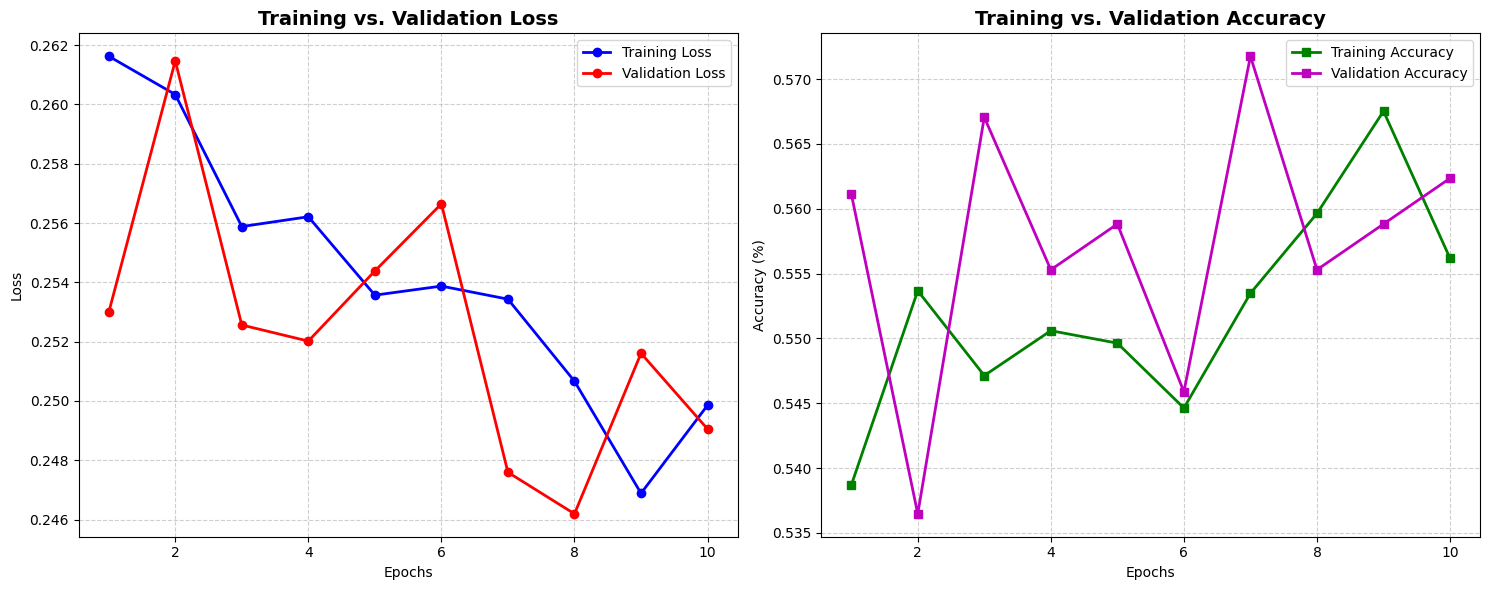

In [ ]:
plot_training_history(scratch_contrastive_trainer.history)

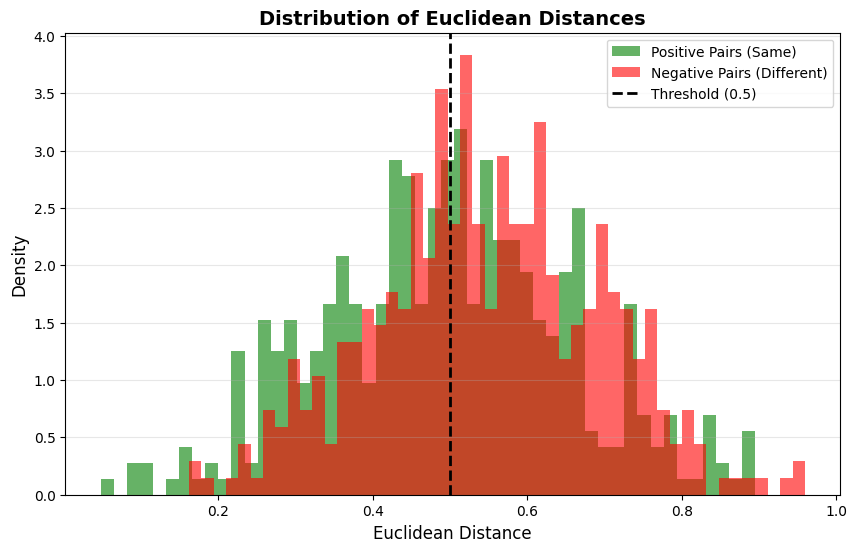

In [ ]:
pos, neg = get_distances_and_labels(scratch_contrastive, val_loader, device, mode='contrastive')
best_t, best_a = find_best_threshold(pos, neg)
plot_distance_distribution(pos, neg, threshold=best_t)

--- Testing Similar Pair ---


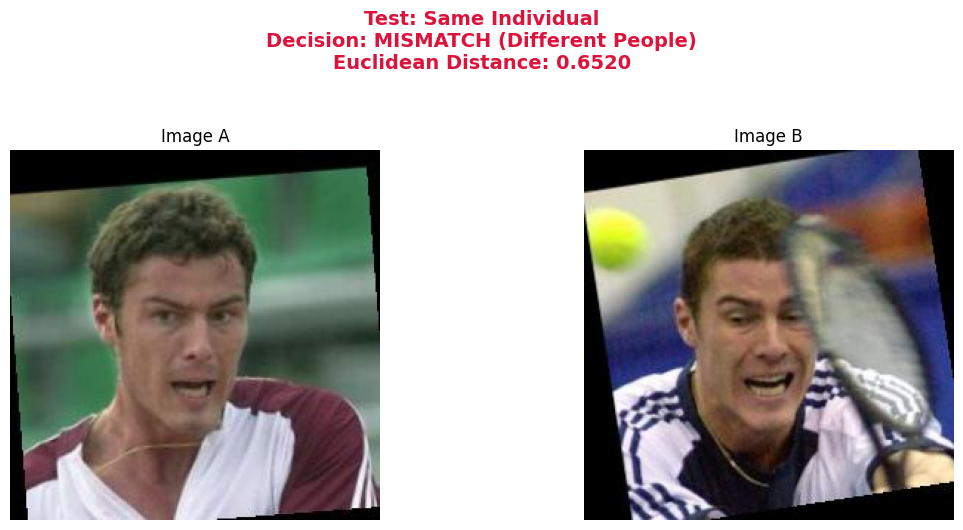


--- Testing Dissimilar Pair ---


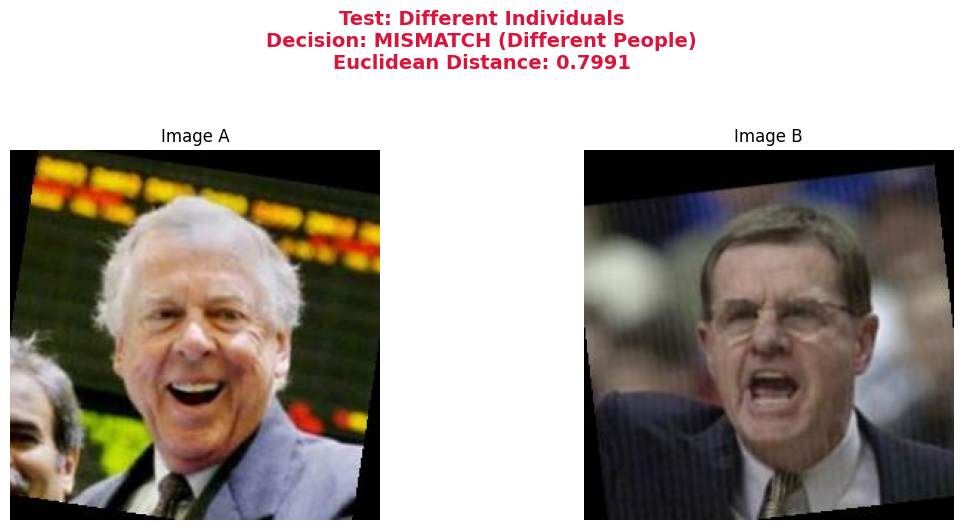

In [ ]:
# Test 1: Same Person
print("--- Testing Similar Pair ---")
dist_sim, result_sim = verify_images(
    model=scratch_contrastive,
    img1_path=sim_path1,
    img2_path=sim_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Same Individual"
)

# Test 2: Different People
print("\n--- Testing Dissimilar Pair ---")
dist_diff, result_diff = verify_images(
    model=scratch_contrastive,
    img1_path=diff_path1,
    img2_path=diff_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Different Individuals"
)

## Triplet Loss

In [ ]:
# 1. Setup
scratch_triplet = CNN_scratch().to(device)

# 2. Optimizer for Head only (higher LR)
optimizer = torch.optim.Adam(scratch_triplet.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# 3. Trainer
scratch_triplet_trainer = SiameseTrainer(scratch_triplet, optimizer, scheduler, train_triplet_loader, val_triplet_loader, device)

print("--- Phase 1: Training Head Only (5 Epochs) ---")
scratch_triplet_trainer.train(epochs=10, mode='triplet')

--- Phase 1: Training Head Only (5 Epochs) ---
Epoch 1/10 -> Train Loss: 0.9565, Train Acc:0.5364 || Val Loss: 0.8908, Val Acc:0.5694
Epoch 2/10 -> Train Loss: 0.9213, Train Acc:0.5579 || Val Loss: 0.8827, Val Acc:0.5788
Epoch 3/10 -> Train Loss: 0.9135, Train Acc:0.5687 || Val Loss: 0.8849, Val Acc:0.5788
Epoch 4/10 -> Train Loss: 0.9064, Train Acc:0.5745 || Val Loss: 0.9060, Val Acc:0.5529
Epoch 5/10 -> Train Loss: 0.9030, Train Acc:0.5825 || Val Loss: 0.8564, Val Acc:0.5906
Epoch 6/10 -> Train Loss: 0.8939, Train Acc:0.5783 || Val Loss: 0.8577, Val Acc:0.5859
Epoch 7/10 -> Train Loss: 0.8924, Train Acc:0.5841 || Val Loss: 0.8709, Val Acc:0.5906
LR reduced from 0.0010 to 0.0001
Epoch 8/10 -> Train Loss: 0.8819, Train Acc:0.5845 || Val Loss: 0.9018, Val Acc:0.5812
Epoch 9/10 -> Train Loss: 0.8844, Train Acc:0.5860 || Val Loss: 0.8935, Val Acc:0.5741
Epoch 10/10 -> Train Loss: 0.8552, Train Acc:0.6002 || Val Loss: 0.8858, Val Acc:0.5812


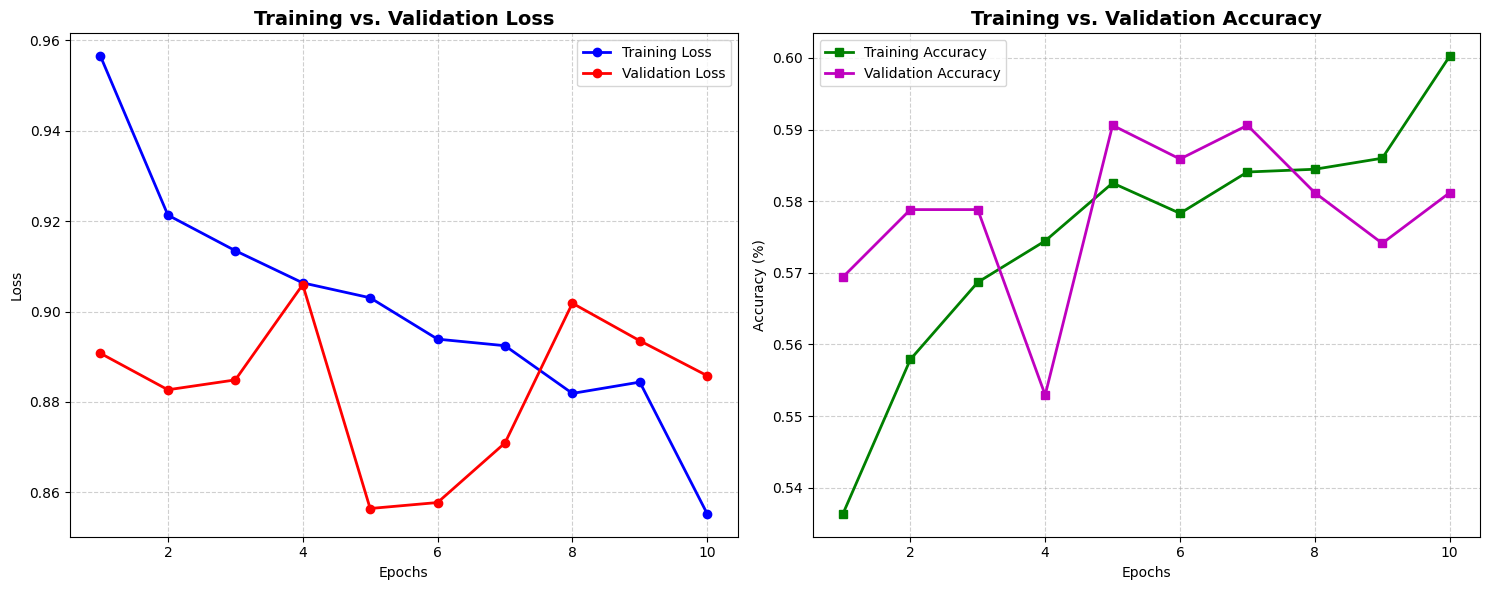

In [ ]:
# Call the function with your trainer's history
plot_training_history(scratch_triplet_trainer.history)

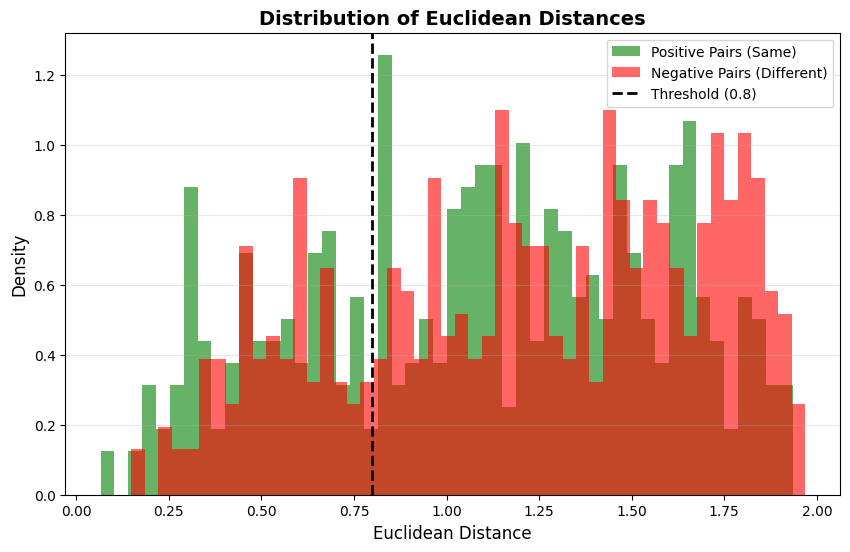

In [ ]:
pos, neg = get_distances_and_labels(scratch_triplet, val_triplet_loader, device, mode='triplet')
best_t, best_a = find_best_threshold(pos, neg)
plot_distance_distribution(pos, neg, threshold=best_t)

--- Testing Similar Pair ---


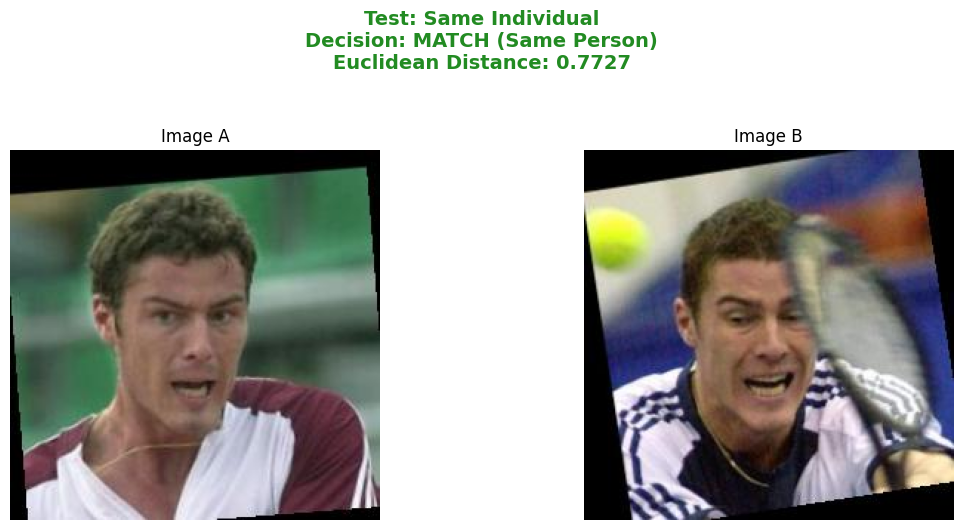


--- Testing Dissimilar Pair ---


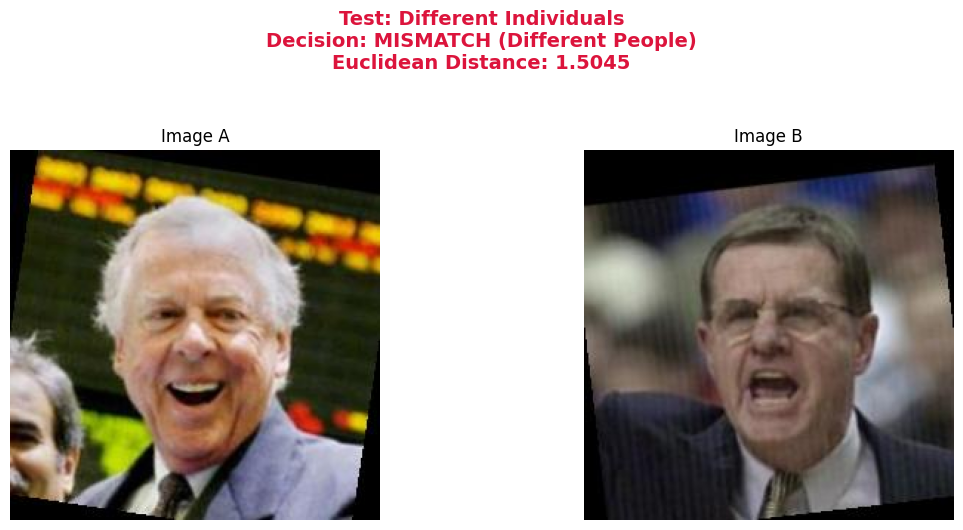

In [ ]:
# Test 1: Same Person
print("--- Testing Similar Pair ---")
dist_sim, result_sim = verify_images(
    model=scratch_triplet,
    img1_path=sim_path1,
    img2_path=sim_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Same Individual"
)

# Test 2: Different People
print("\n--- Testing Dissimilar Pair ---")
dist_diff, result_diff = verify_images(
    model=scratch_triplet,
    img1_path=diff_path1,
    img2_path=diff_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Different Individuals"
)

# Transfer Learning

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

class SiameseResNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super(SiameseResNet, self).__init__()
        self.resnet = models.resnet18(weights='IMAGENET1K_V1')
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        x = self.resnet(x)
        x = self.head(x)
        return F.normalize(x, p=2, dim=1)

    def set_backbone_freeze(self, freeze=True):
        for param in self.resnet.parameters():
            param.requires_grad = not freeze

## Contrastive Loss

In [ ]:
# 1. Setup
resnet_contrastive = SiameseResNet().to(device)
resnet_contrastive.set_backbone_freeze(True) # Freeze ResNet

# 2. Optimizer for Head only (higher LR)
optimizer_head = torch.optim.Adam(resnet_contrastive.head.parameters(), lr=1e-3)

# 3. Trainer
resnet_contrastive_trainer = SiameseTrainer(resnet_contrastive, optimizer_head, None, train_loader, val_loader, device)

print("--- Phase 1: Training Head Only (5 Epochs) ---")
resnet_contrastive_trainer.train(epochs=5, mode='contrastive')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


--- Phase 1: Training Head Only (5 Epochs) ---
Epoch 1/5 -> Train Loss: 0.2071, Train Acc:0.6668 || Val Loss: 0.1830, Val Acc:0.7341
Epoch 2/5 -> Train Loss: 0.1823, Train Acc:0.7266 || Val Loss: 0.1885, Val Acc:0.6929
Epoch 3/5 -> Train Loss: 0.1710, Train Acc:0.7486 || Val Loss: 0.1815, Val Acc:0.7271
Epoch 4/5 -> Train Loss: 0.1669, Train Acc:0.7651 || Val Loss: 0.1745, Val Acc:0.7412
Epoch 5/5 -> Train Loss: 0.1624, Train Acc:0.7734 || Val Loss: 0.1732, Val Acc:0.7600


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
print("\n--- Phase 2: Unfreezing Backbone and Fine-Tuning (10 Epochs) ---")
resnet_contrastive.set_backbone_freeze(False) # Unfreeze everything

# New optimizer with lower LR for everything
optimizer_full = torch.optim.Adam(resnet_contrastive.parameters(), lr=5e-5,weight_decay=1e-4)

# New scheduler for the fine-tuning phase
scheduler = ReduceLROnPlateau(optimizer_full, mode='min', factor=0.1, patience=2)

# Update trainer with new optimizer/scheduler
resnet_contrastive_trainer.optimizer = optimizer_full
resnet_contrastive_trainer.scheduler = scheduler

resnet_contrastive_trainer.train(epochs=6, mode='contrastive')


--- Phase 2: Unfreezing Backbone and Fine-Tuning (10 Epochs) ---
Epoch 1/6 -> Train Loss: 0.1377, Train Acc:0.8120 || Val Loss: 0.1264, Val Acc:0.8282
Epoch 2/6 -> Train Loss: 0.1029, Train Acc:0.8850 || Val Loss: 0.1186, Val Acc:0.8365
Epoch 3/6 -> Train Loss: 0.0875, Train Acc:0.9119 || Val Loss: 0.1204, Val Acc:0.8447
Epoch 4/6 -> Train Loss: 0.0759, Train Acc:0.9334 || Val Loss: 0.1200, Val Acc:0.8376
Epoch 5/6 -> Train Loss: 0.0678, Train Acc:0.9479 || Val Loss: 0.1149, Val Acc:0.8471
Epoch 6/6 -> Train Loss: 0.0602, Train Acc:0.9579 || Val Loss: 0.1155, Val Acc:0.8494


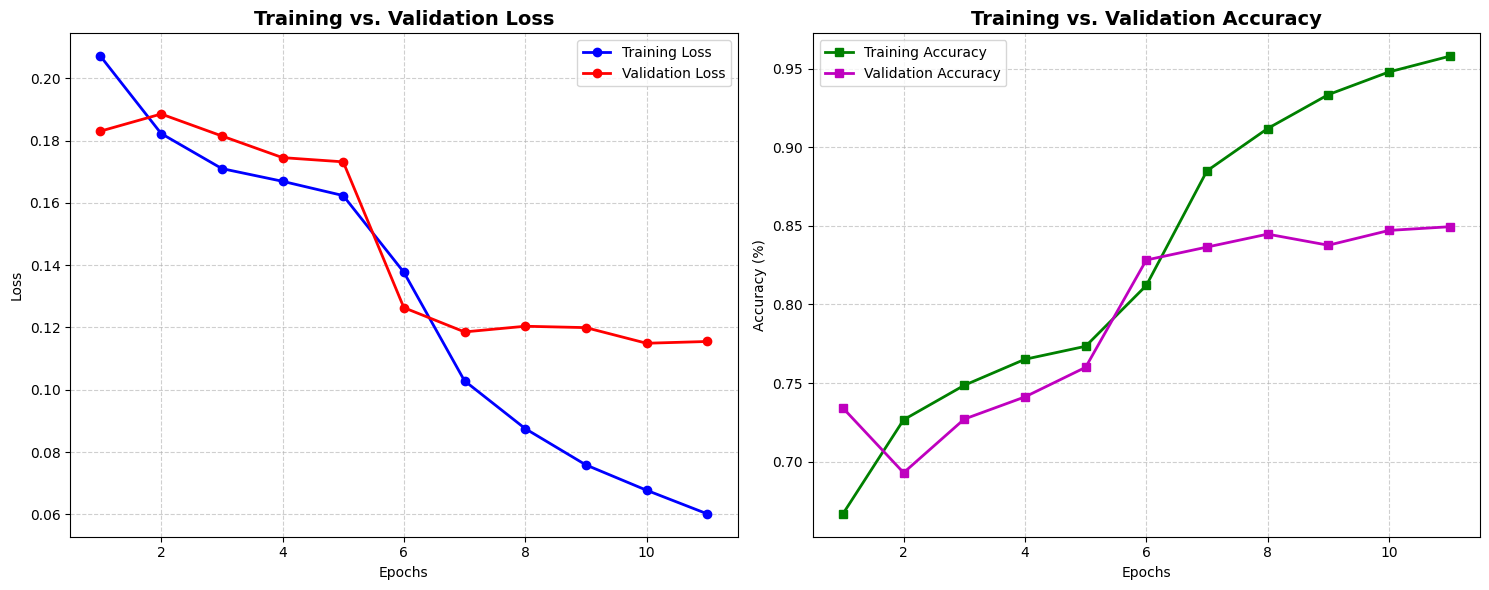

In [ ]:
plot_training_history(resnet_contrastive_trainer.history)

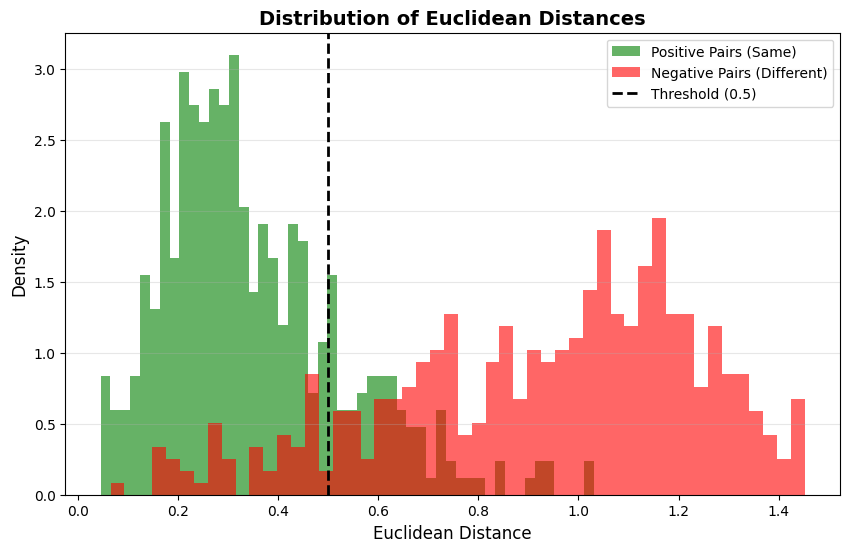

In [ ]:
pos, neg = get_distances_and_labels(resnet_contrastive, val_loader, device, mode='contrastive')
best_t, best_a = find_best_threshold(pos, neg)
plot_distance_distribution(pos, neg, threshold=best_t)

--- Testing Similar Pair ---


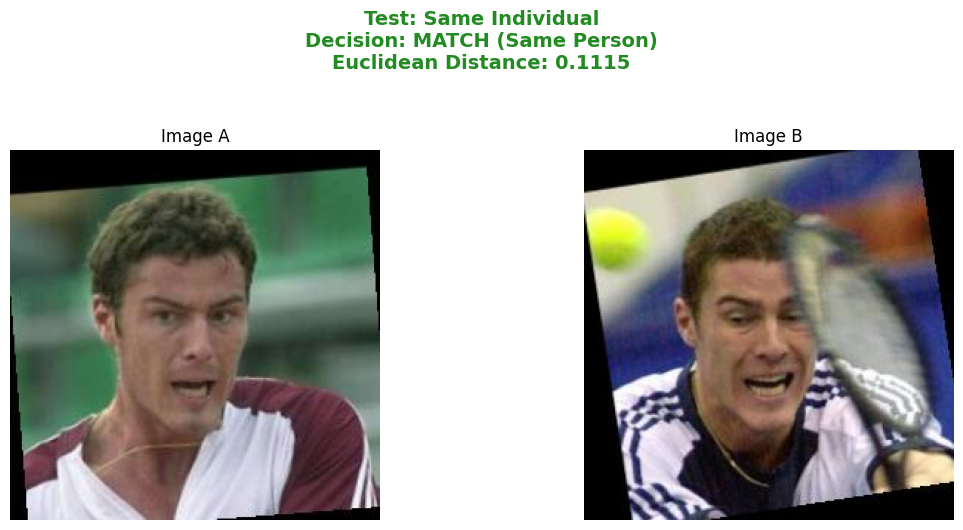


--- Testing Dissimilar Pair ---


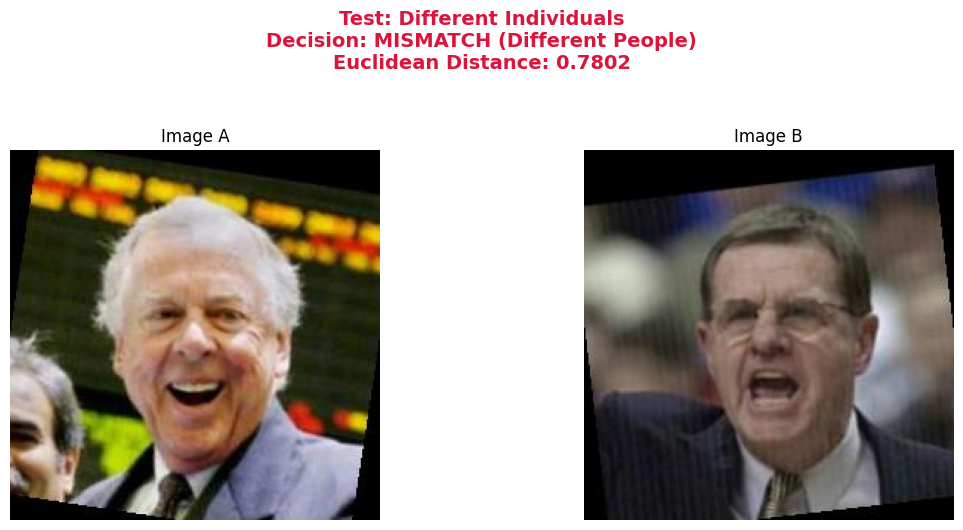

In [ ]:
# Test 1: Same Person
print("--- Testing Similar Pair ---")
dist_sim, result_sim = verify_images(
    model=resnet_contrastive,
    img1_path=sim_path1,
    img2_path=sim_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Same Individual"
)

# Test 2: Different People
print("\n--- Testing Dissimilar Pair ---")
dist_diff, result_diff = verify_images(
    model=resnet_contrastive,
    img1_path=diff_path1,
    img2_path=diff_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Different Individuals"
)

## Triplet Loss

In [ ]:
# 1. Setup
resnet_triplet = SiameseResNet().to(device)
resnet_triplet.set_backbone_freeze(True) # Freeze ResNet

# 2. Optimizer for Head only (higher LR)
optimizer_head = torch.optim.Adam(resnet_triplet.head.parameters(), lr=1e-3)

# 3. Trainer
resnet_triplet_trainer = SiameseTrainer(resnet_triplet, optimizer_head, None, train_triplet_loader, val_triplet_loader, device)

print("--- Phase 1: Training Head Only (5 Epochs) ---")
resnet_triplet_trainer.train(epochs=5, mode='triplet')

--- Phase 1: Training Head Only (5 Epochs) ---
Epoch 1/5 -> Train Loss: 0.6732, Train Acc:0.7699 || Val Loss: 0.6288, Val Acc:0.7553
Epoch 2/5 -> Train Loss: 0.5539, Train Acc:0.8084 || Val Loss: 0.5911, Val Acc:0.7341
Epoch 3/5 -> Train Loss: 0.5303, Train Acc:0.8157 || Val Loss: 0.5779, Val Acc:0.7788
Epoch 4/5 -> Train Loss: 0.5013, Train Acc:0.8292 || Val Loss: 0.5635, Val Acc:0.7976
Epoch 5/5 -> Train Loss: 0.4793, Train Acc:0.8407 || Val Loss: 0.5453, Val Acc:0.8188


In [ ]:
print("\n--- Phase 2: Unfreezing Backbone and Fine-Tuning (10 Epochs) ---")
resnet_triplet.set_backbone_freeze(False) # Unfreeze everything

# New optimizer with lower LR for everything
optimizer_full = torch.optim.Adam(resnet_triplet.parameters(), lr=5e-5,weight_decay=1e-4)

# New scheduler for the fine-tuning phase
scheduler = ReduceLROnPlateau(optimizer_full, mode='min', factor=0.1, patience=2)

# Update trainer with new optimizer/scheduler
resnet_triplet_trainer.optimizer = optimizer_full
resnet_triplet_trainer.scheduler = scheduler

resnet_triplet_trainer.train(epochs=6, mode='triplet')


--- Phase 2: Unfreezing Backbone and Fine-Tuning (10 Epochs) ---
Epoch 1/6 -> Train Loss: 0.4108, Train Acc:0.8773 || Val Loss: 0.4314, Val Acc:0.8776
Epoch 2/6 -> Train Loss: 0.3105, Train Acc:0.9284 || Val Loss: 0.3844, Val Acc:0.8824
Epoch 3/6 -> Train Loss: 0.2456, Train Acc:0.9473 || Val Loss: 0.3798, Val Acc:0.8894
Epoch 4/6 -> Train Loss: 0.2132, Train Acc:0.9684 || Val Loss: 0.3470, Val Acc:0.9082
Epoch 5/6 -> Train Loss: 0.1812, Train Acc:0.9777 || Val Loss: 0.3640, Val Acc:0.9106
Epoch 6/6 -> Train Loss: 0.1650, Train Acc:0.9800 || Val Loss: 0.3497, Val Acc:0.9153


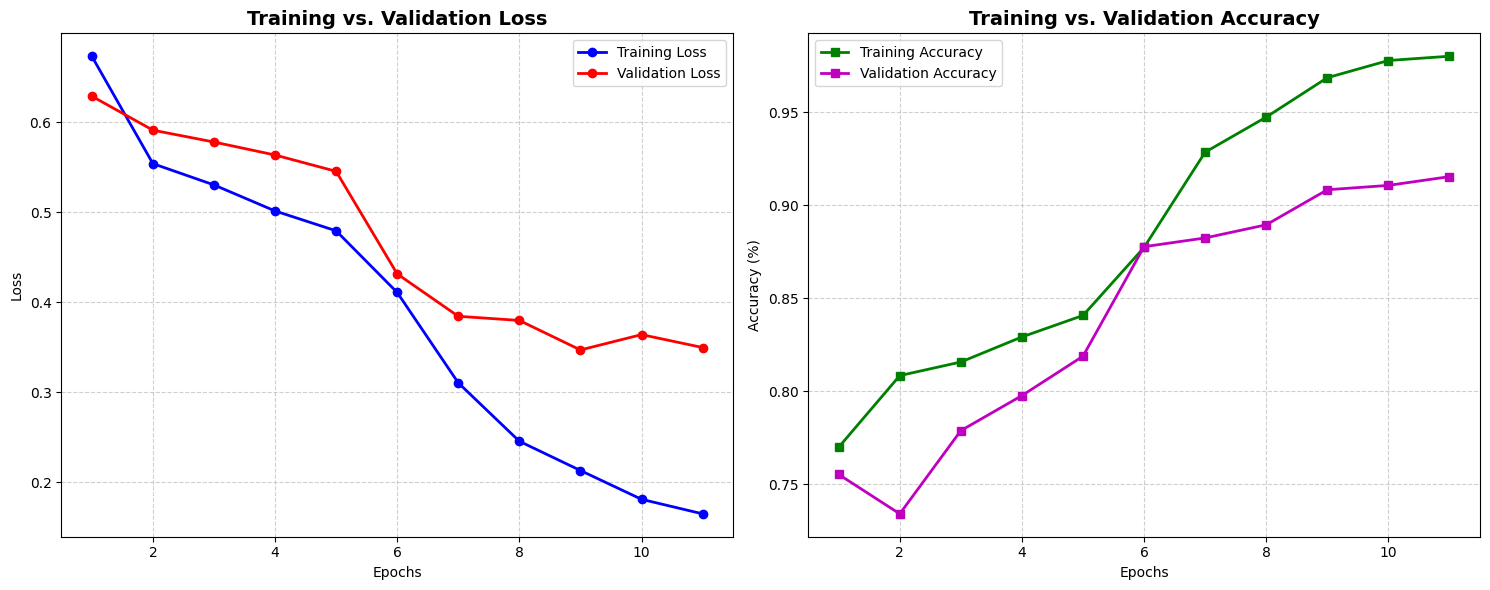

In [ ]:
# Call the function with your trainer's history
plot_training_history(resnet_triplet_trainer.history)

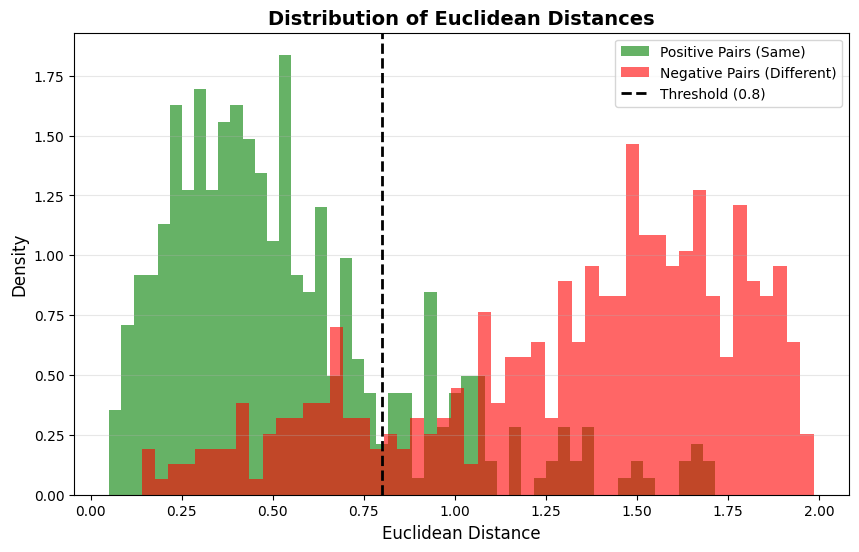

In [ ]:
pos, neg = get_distances_and_labels(resnet_triplet, val_triplet_loader, device, mode='triplet')
best_t, best_a = find_best_threshold(pos, neg)
plot_distance_distribution(pos, neg, threshold=best_t)

--- Testing Similar Pair ---


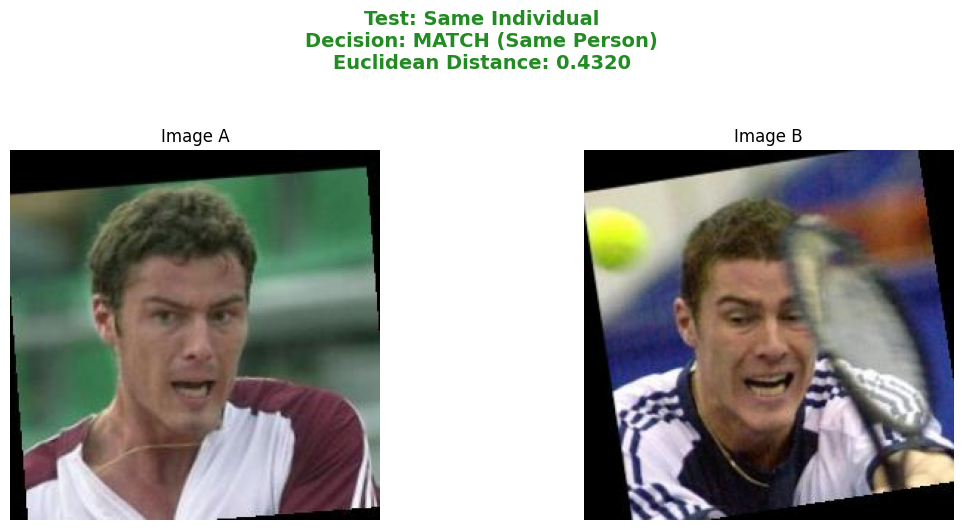


--- Testing Dissimilar Pair ---


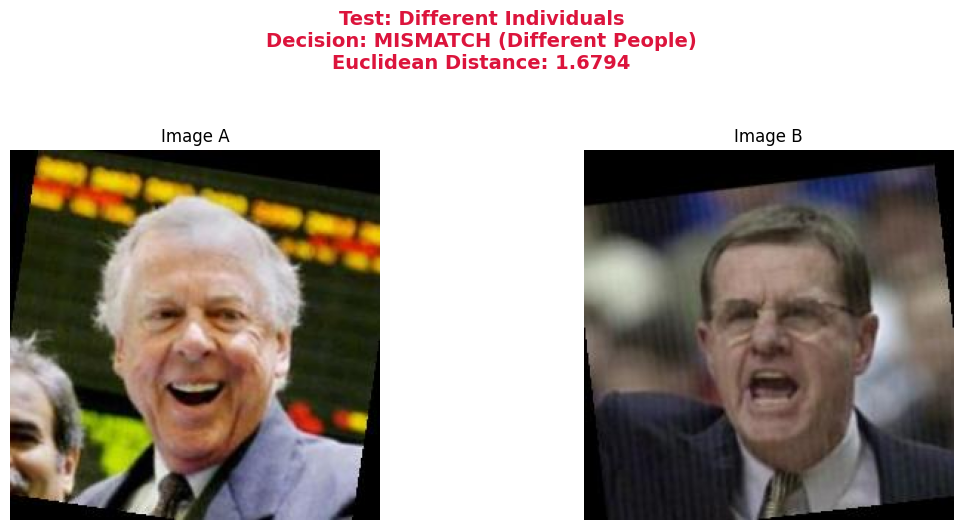

In [ ]:
# Test 1: Same Person
print("--- Testing Similar Pair ---")
dist_sim, result_sim = verify_images(
    model=resnet_triplet,
    img1_path=sim_path1,
    img2_path=sim_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Same Individual"
)

# Test 2: Different People
print("\n--- Testing Dissimilar Pair ---")
dist_diff, result_diff = verify_images(
    model=resnet_triplet,
    img1_path=diff_path1,
    img2_path=diff_path2,
    transform=val_transforms,
    device=device,
    threshold=best_t,
    title="Test: Different Individuals"
)

In [ ]:
zero_shot_acc, pos_dist, neg_dist = evaluate_zero_shot(resnet_triplet, testing_data, val_transforms, device)
print(f"Zero-Shot Total Accuracy: {zero_shot_acc * 100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

def plot_zero_shot_histogram(pos_dist, neg_dist, threshold):
    plt.figure(figsize=(10, 6))

    # Plotting the distributions
    plt.hist(pos_dist, bins=30, alpha=0.6, color='blue', label='Positive Pairs (Same Person)', density=True)
    plt.hist(neg_dist, bins=30, alpha=0.6, color='red', label='Negative Pairs (Different People)', density=True)

    # Adding the threshold line
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

    plt.title('Zero-Shot Euclidean Distance Distribution (< 5 Images)')
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Density')
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

    plt.savefig('resnet_zeroshot_dist.png') # This saves the file for your LaTeX report
    plt.show()

# Run the plotting function
plot_zero_shot_histogram(pos_dist, neg_dist, threshold=0.55)